<a href="https://colab.research.google.com/github/LuisVitorVaz/Craindo-meu-rpoprio-jogo/blob/main/challenge_telecom_parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Instalar bibliotecas extras se o ambiente não tiver
!pip install -q scikit-learn seaborn imbalanced-learn

In [4]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/main/TelecomX_Data.json"

df = pd.read_json(url)

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [5]:
import pandas as pd
import requests

url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/main/TelecomX_Data.json"

data = requests.get(url).json()

df = pd.json_normalize(data)

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [6]:
df.columns = df.columns.str.replace('.', '_')
df.columns

Index(['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod',
       'account_Charges_Monthly', 'account_Charges_Total'],
      dtype='object')

In [16]:
df["Churn"] = df["Churn"].replace({
    "Yes":1,
    "No":0,
    "Sim":1,
    "Não":0
})
df["Churn"] = pd.to_numeric(df["Churn"], errors="coerce")

In [17]:
df = df.drop(columns=["customerID"], errors="ignore")

In [18]:
df["account_Charges_Total"] = pd.to_numeric(df["account_Charges_Total"], errors="coerce")

In [19]:
df = df.dropna()

In [20]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (7032, 19)
Target: (7032,)


In [21]:
X = pd.get_dummies(X, drop_first=True)

print("Total de variáveis após encoding:", X.shape[1])
X.head()

Total de variáveis após encoding: 30


,customer_SeniorCitizen,customer_tenure,account_Charges_Monthly,account_Charges_Total,customer_gender_Male,customer_Partner_Yes,customer_Dependents_Yes,phone_PhoneService_Yes,phone_MultipleLines_No phone service,phone_MultipleLines_Yes,...,internet_StreamingTV_No internet service,internet_StreamingTV_Yes,internet_StreamingMovies_No internet service,internet_StreamingMovies_Yes,account_Contract_One year,account_Contract_Two year,account_PaperlessBilling_Yes,account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check
0,0,9,65.6,593.30,False,True,True,True,False,False,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,True,False,False,True,False,True,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,True,True,False,True,False,False,...,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,False,True,False,True,False,False,...,False,True,False,False,False,False,True,False,False,True


Proporção de Churn:
Churn
0.0    73.421502
1.0    26.578498
Name: proportion, dtype: float64


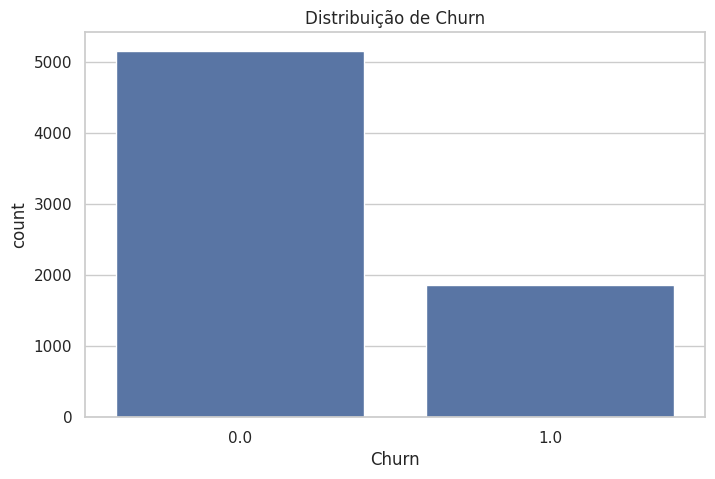

In [22]:
churn_ratio = y.value_counts(normalize=True) * 100

print("Proporção de Churn:")
print(churn_ratio)

import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)
plt.title("Distribuição de Churn")
plt.show()

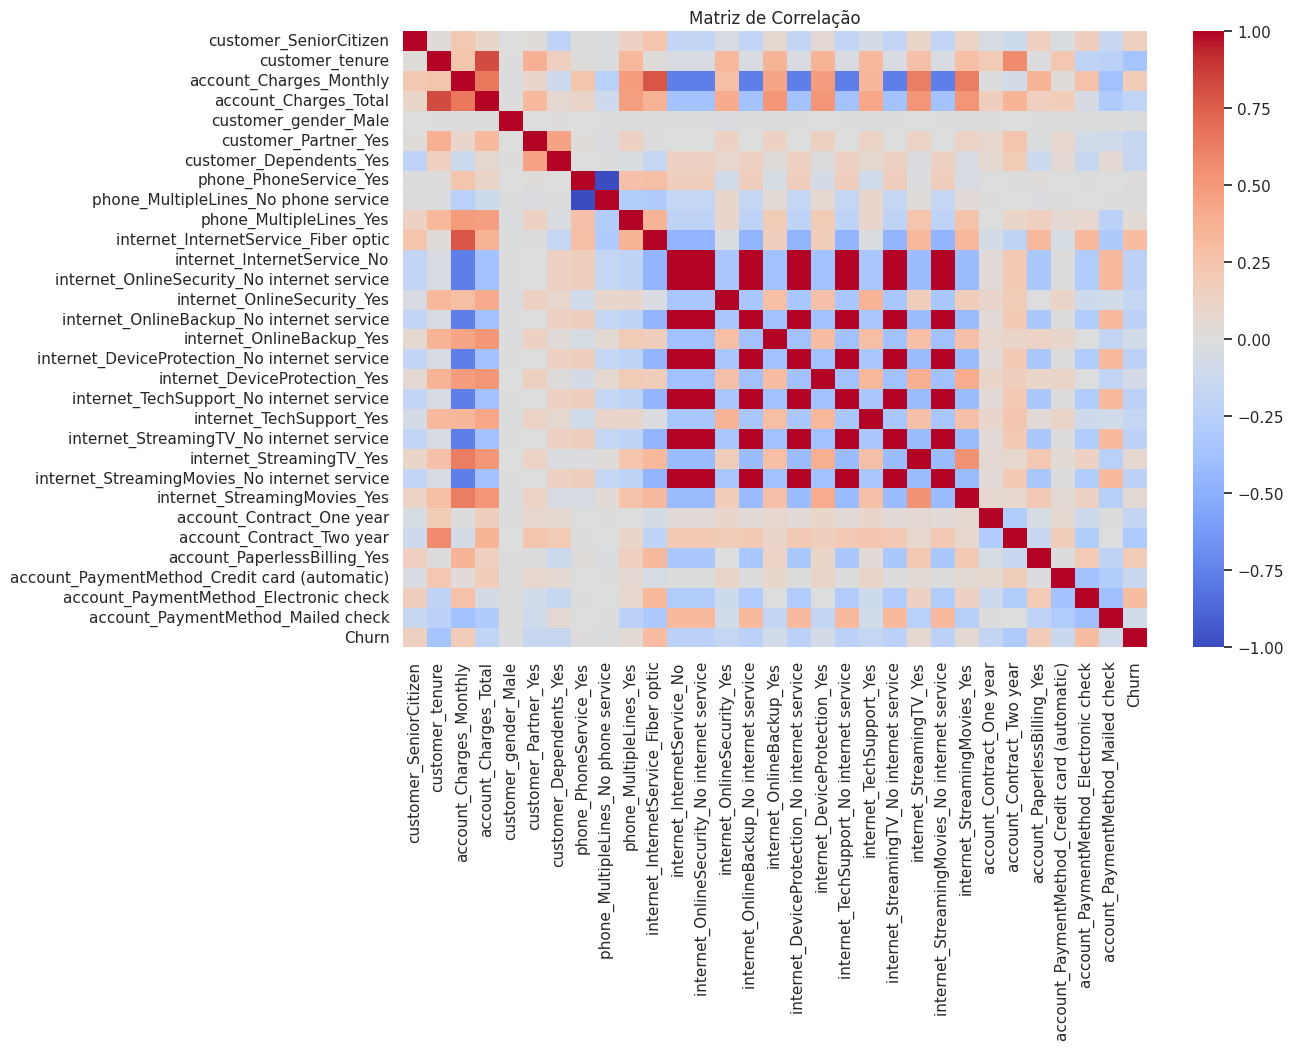

In [23]:
import pandas as pd

corr_matrix = pd.concat([X, y], axis=1).corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()

In [24]:
corr_churn = corr_matrix["Churn"].sort_values(ascending=False)

print(corr_churn.head(15))

Churn                                     1.000000
internet_InternetService_Fiber optic      0.307463
account_PaymentMethod_Electronic check    0.301455
account_Charges_Monthly                   0.192858
account_PaperlessBilling_Yes              0.191454
customer_SeniorCitizen                    0.150541
internet_StreamingTV_Yes                  0.063254
internet_StreamingMovies_Yes              0.060860
phone_MultipleLines_Yes                   0.040033
phone_PhoneService_Yes                    0.011691
customer_gender_Male                     -0.008545
phone_MultipleLines_No phone service     -0.011691
internet_DeviceProtection_Yes            -0.066193
internet_OnlineBackup_Yes                -0.082307
account_PaymentMethod_Mailed check       -0.090773
Name: Churn, dtype: float64


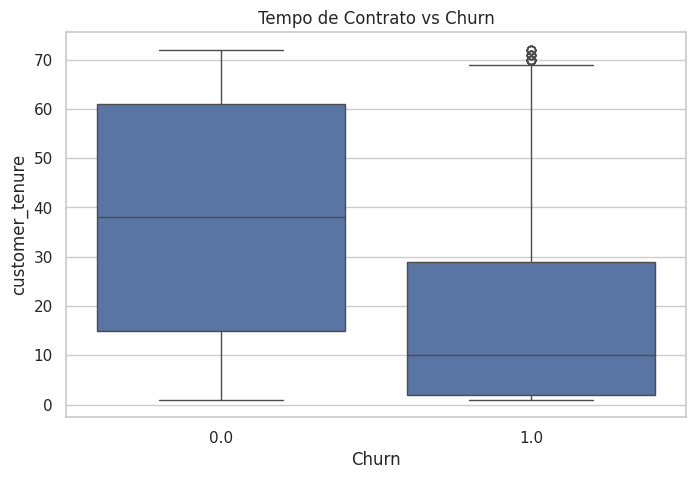

In [25]:
if "customer_tenure" in df.columns:

    sns.boxplot(x="Churn", y="customer_tenure", data=df)
    plt.title("Tempo de Contrato vs Churn")
    plt.show()

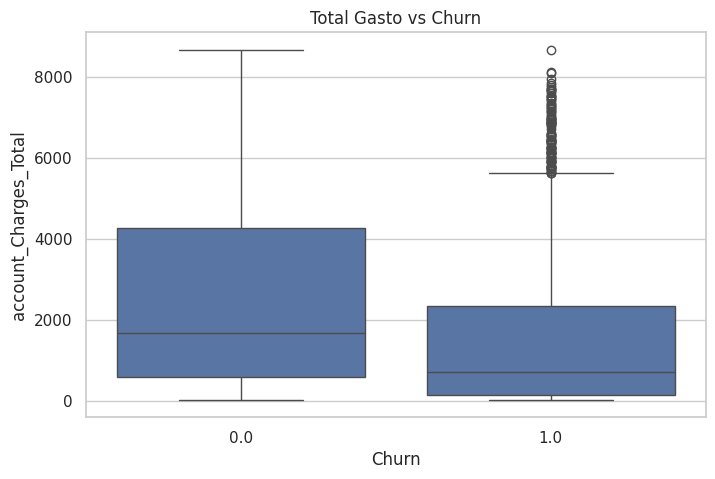

In [26]:
if "account_Charges_Total" in df.columns:

    sns.boxplot(x="Churn", y="account_Charges_Total", data=df)
    plt.title("Total Gasto vs Churn")
    plt.show()

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (4922, 30)
Teste: (2110, 30)


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [29]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

def avaliar_modelo(y_true, y_pred):

    print("Acurácia:", accuracy_score(y_true,y_pred))
    print("Precisão:", precision_score(y_true,y_pred))
    print("Recall:", recall_score(y_true,y_pred))
    print("F1-score:", f1_score(y_true,y_pred))

    print("\nRelatório de Classificação:\n")
    print(classification_report(y_true,y_pred))

    cm = confusion_matrix(y_true,y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.show()

Resultados — Regressão Logística

Acurácia: 0.8033175355450237
Precisão: 0.6573275862068966
Recall: 0.5436720142602496
F1-score: 0.5951219512195122

Relatório de Classificação:

              precision    recall  f1-score   support

         0.0       0.84      0.90      0.87      1549
         1.0       0.66      0.54      0.60       561

    accuracy                           0.80      2110
   macro avg       0.75      0.72      0.73      2110
weighted avg       0.79      0.80      0.80      2110



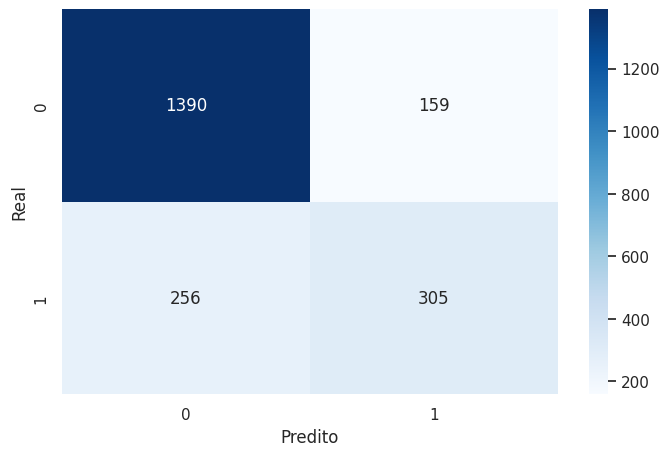

In [32]:
print("Resultados — Regressão Logística\n")

avaliar_modelo(y_test, y_pred_log)

Resultados — Random Forest

Acurácia: 0.7848341232227488
Precisão: 0.621867881548975
Recall: 0.48663101604278075
F1-score: 0.546

Relatório de Classificação:

              precision    recall  f1-score   support

         0.0       0.83      0.89      0.86      1549
         1.0       0.62      0.49      0.55       561

    accuracy                           0.78      2110
   macro avg       0.72      0.69      0.70      2110
weighted avg       0.77      0.78      0.78      2110



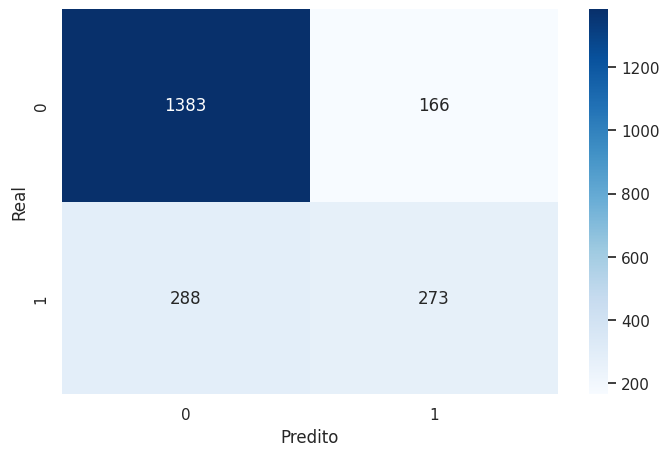

In [33]:
print("Resultados — Random Forest\n")

avaliar_modelo(y_test, y_pred_rf)

In [34]:
import pandas as pd

importances = rf_model.feature_importances_

feat_import = pd.Series(importances, index=X.columns)
feat_import = feat_import.sort_values(ascending=False)

feat_import.head(15)

,0
account_Charges_Total,0.191118
account_Charges_Monthly,0.170190
customer_tenure,0.169279
account_PaymentMethod_Electronic check,0.040759
internet_InternetService_Fiber optic,0.039438
account_Contract_Two year,0.030721
customer_gender_Male,0.029116
account_PaperlessBilling_Yes,0.025096
internet_OnlineSecurity_Yes,0.024912
internet_TechSupport_Yes,0.023649


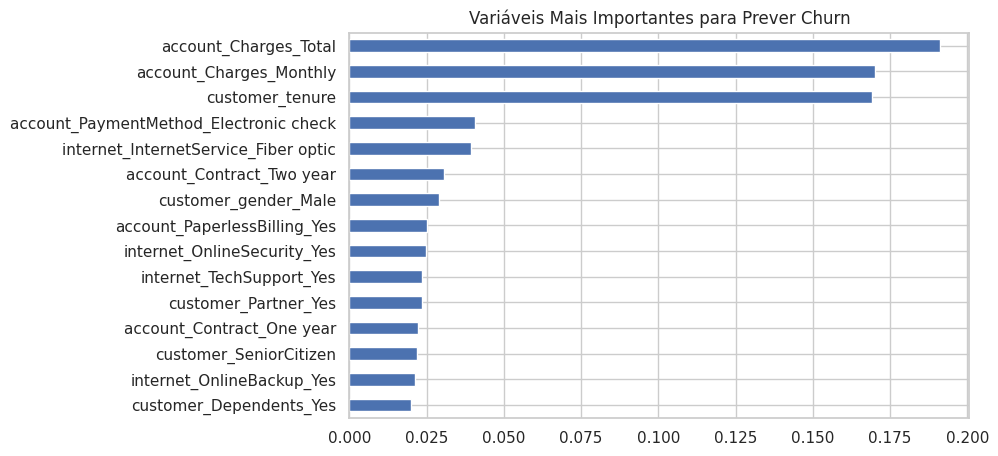

In [35]:
feat_import.head(15).plot(kind="barh")

plt.title("Variáveis Mais Importantes para Prever Churn")
plt.gca().invert_yaxis()

plt.show()

In [36]:
coef = pd.Series(log_model.coef_[0], index=X.columns)

coef = coef.sort_values()

coef.tail(10)

,0
phone_MultipleLines_No phone service,0.019353
internet_DeviceProtection_Yes,0.038262
customer_SeniorCitizen,0.094955
phone_MultipleLines_Yes,0.129529
internet_StreamingMovies_Yes,0.156266
account_PaperlessBilling_Yes,0.180289
account_PaymentMethod_Electronic check,0.183835
internet_StreamingTV_Yes,0.201481
internet_InternetService_Fiber optic,0.594341
account_Charges_Total,0.626025


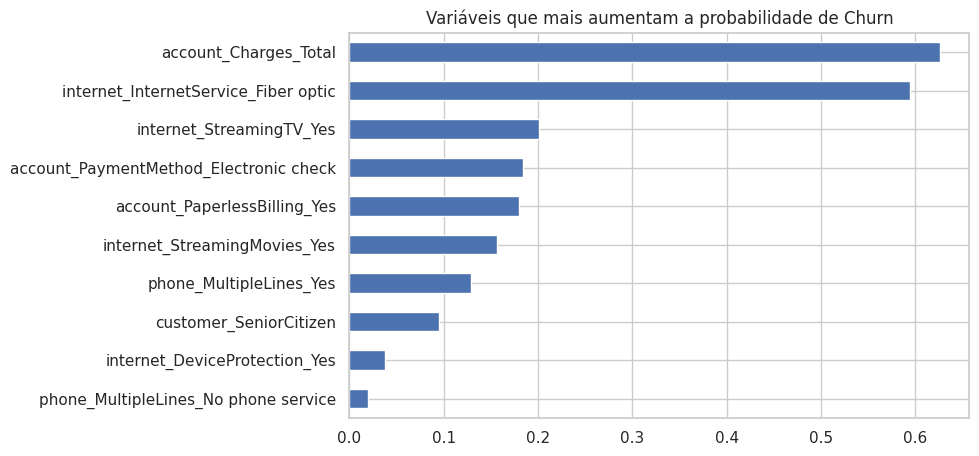

In [37]:
coef.tail(10).plot(kind="barh")

plt.title("Variáveis que mais aumentam a probabilidade de Churn")

plt.show()